In [209]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [210]:
def f(x):
    return 3*x**2 - 4*x + 5

In [211]:
f(3.0)

20.0

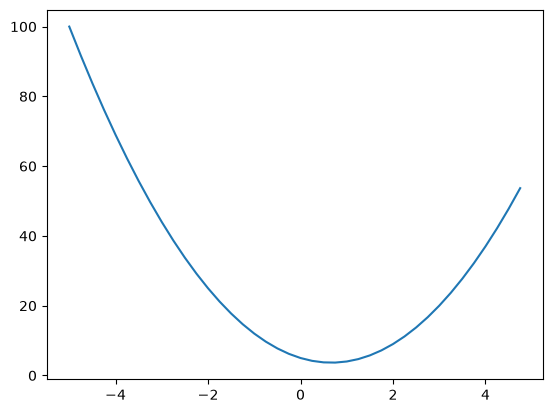

In [212]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
ys
plt.plot(xs, ys)

In [213]:
# --- Numerical derivative ---
# The derivative tells us: if I nudge x by a tiny amount h,
# how much does f(x) change, and in which direction?
#
# Definition:  f'(x) = lim (h -> 0) of  (f(x + h) - f(x)) / h
#
#   f(x + h) - f(x)   -> how much the output changed ("rise")
#   / h               -> divided by how much we nudged the input ("run")
#   = slope of f at x -> the sensitivity of the output to the input
#
# Here f(x) = 3x^2 - 4x + 5, so analytically f'(x) = 6x - 4
# At x = 3.0: f'(3) = 6*3 - 4 = 14, and the numerical estimate should be ~14.
#
# Sign of the derivative:
#   positive -> increasing x increases f
#   negative -> increasing x decreases f
#   zero     -> f is flat here (e.g. the minimum of the parabola, at x = 2/3)
#
# Note: h must be small, but not TOO small. With a very tiny h, floating-point
# rounding errors dominate and the result becomes inaccurate.
#
# Why this matters: training a neural network means finding out how the loss
# changes when each weight is nudged, which is exactly this idea. Backprop
# is just an efficient way to compute these derivatives for every weight at once.

h = 0.00000001
x = 3.0
(f(x + h) - f(x)) / h

14.00000009255109

In [214]:
a = 2.0
b = -3.0
c = 10.0
d = a*b + c 
print(d)

4.0


In [215]:
h = 0.000001

#inputs 
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 -d1)/h)

d1 4.0
d2 3.9999969999999996
slope -3.000000000419334


In [360]:
class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(label={self.label}, data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)  #this permits additions with int, before both had do be Value isntants 
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():  
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad

        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supports int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other-1)) * out.grad
        out._backward = _backward

        return out

    def __rmul__(self, other):  # this is used so we can do 2 * a, before that we could only do a * 2
        return self * other

    def __radd__(self, other):  # allows other + self, e.g. 0 + Value, needed by sum()
        return self + other

    def __truediv__(self, other):
        return self * other**(-1)

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad +=  (1- t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []          # the ordered list we're building
        visited = set()    # nodes we've already processed, so none is added twice

        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:   # first, process everything that created v...
                    build_topo(child)
                topo.append(v)          # ...then add v itself, after all its children

        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

a = Value(2.0, label = 'a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label= 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(label=L, data=-8.0)

In [291]:
a = Value(2.0)
a*3
a.exp()

b = Value(4.0)

a / b

a - b

Value(label=, data=-2.0)

In [243]:
from graphviz import Digraph

def trace(root):
    #builds a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any  vlaue in the grpah, create a rectangular (;record') node for it
        dot.node(name = uid, label= "{%s | data %.4f | grad %.4f }" %(n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this values is a result of some operation, create an 'op; node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node for n2 
        dot.edge(str(id(n1)), str(id(n2)) +n2._op)
    return dot

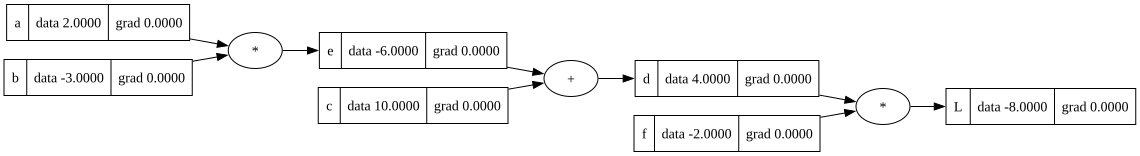

In [218]:
draw_dot(L)

   **dL/dd**, where L = d · f

   (L(d+h) - L(d)) / h
   = ((d+h)·f - d·f) / h
   = (d·f + f·h - d·f) / h
   = f·h / h
   = f

In [219]:
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
c.grad = -2.0
e.grad = -2.0
a.grad = -2.0 * 3.0
b.grad = -2.0 * 2.0

In [220]:
dd / dc  

d = c + e

f(x+h) - f(x) / h

(c + h + e) - (c + e)/h

1.0 


NameError: name 'dd' is not defined

In [221]:
def lol ():

    h = 0.001

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label= 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L1 = L.data

    a = Value(2.0, label = 'a')
    b = Value(-3.0, label = 'b')
    c = Value(10.0, label= 'c')
    e = a*b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = d * f; L.label = 'L'
    L2 = L.data + h

    print((L2 - L1)/h)

lol()

1.000000000000334


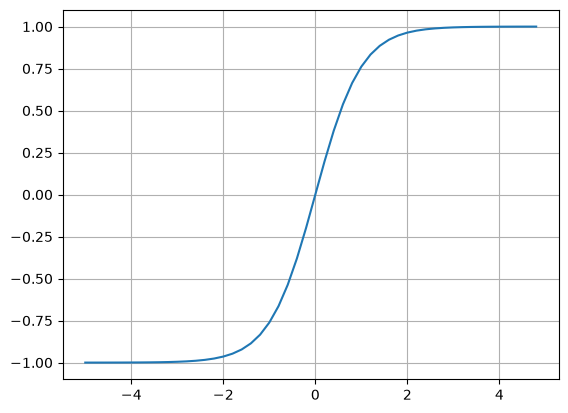

In [222]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2))); plt.grid();

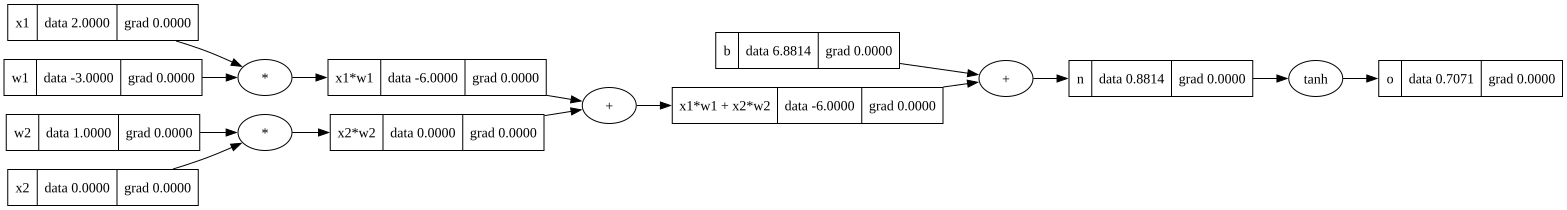

In [316]:
# inputs x1, x2

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron

b = Value(6.8813735870195432, label = 'b')

# x1 * w1 + x2 * w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

draw_dot(o)

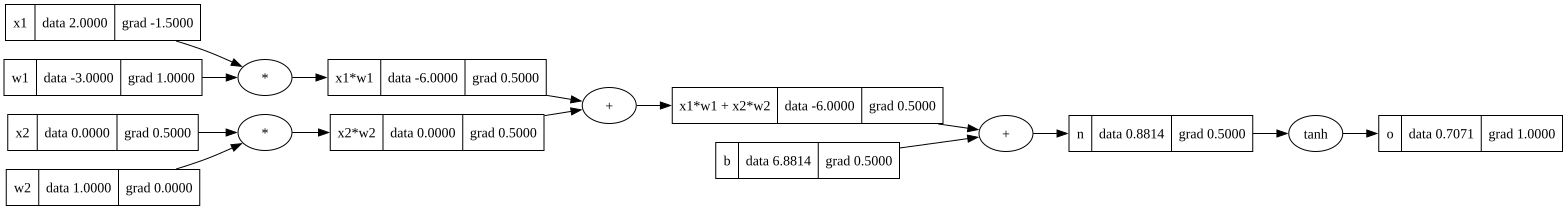

In [300]:
draw_dot(o)

In [295]:
o.grad = 1.0

In [296]:
o._backward()

In [297]:
n._backward()

In [ ]:
b._backward() #nothing happens cause b is a leaf

AttributeError: 'Value' object has no attribute '_backward'

In [298]:
x1w1x2w2._backward()

In [299]:
x1w1._backward()
x2w2._backward()

## The `_backward` function

`_backward` automates the manual backpropagation we did by hand.
Each operation (`+`, `*`, `tanh`) stores its own local derivative rule,
and applies the chain rule: `child.grad += local_derivative * out.grad`.

This gives **exact** gradients using calculus, unlike the numerical
method (nudging by h), which only approximates them and is used to
**check** that our `_backward` rules are correct.

### Order matters: start from the end

Backprop must start from the output (`L.grad = 1`) and go backward,
because each node's `_backward` needs its output's gradient to already
be final.

**Chain:** `1 → 2 → 3 → 4 → 5` (5 is the output)
To find `2.grad`, we first need `3.grad`, which needs `4.grad`,
which needs `5.grad`. Order: 5 → 4 → 3 → 2 → 1.

**Rule:** a node's gradient needs the gradients of every node that
depends on it (everything after it on its paths to the output).
Nodes on separate branches are not needed.

**Branching:** if node 2 feeds into both 3 and 4, and both lead to 5:

```
     ┌→ 3 ──┐
1 → 2       5
     └→ 4 ──┘
```

`2.grad` needs both `3.grad` and `4.grad`, and its gradient is the
**sum** of the contributions from both paths. This is why `_backward`
uses `+=` instead of `=`.

A **topological sort** puts the nodes in an order where every node comes
after its children; walking it in reverse guarantees each node is
processed only after everything that depends on it.

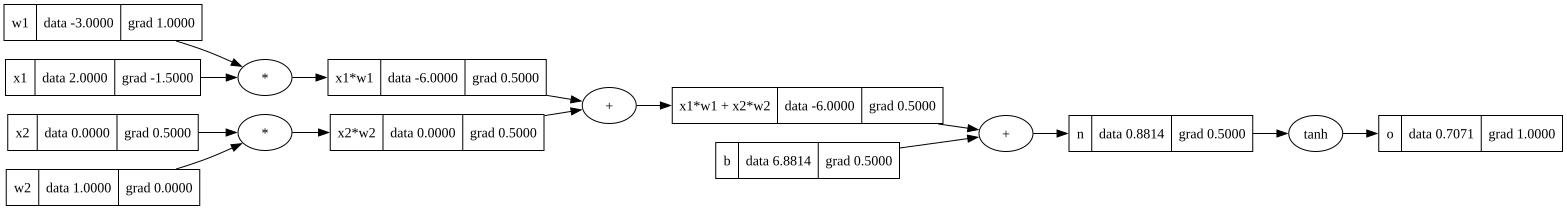

In [236]:
draw_dot(o)

In [233]:
# --- Manual backprop through the neuron ---
# Forward pass: n = x1*w1 + x2*w2 + b,  o = tanh(n)

# o is the output, so we start there: do/do = 1
o.grad = 1.0

# o = tanh(n)  →  local derivative do/dn = 1 - tanh(n)**2 = 1 - o**2
# (from calculus, or the "Hyperbolic functions" page on Wikipedia)
# o ≈ 0.7071, so 1 - 0.7071**2 = 0.5
# chain rule: n.grad = (1 - o**2) * o.grad = 0.5 * 1
n.grad = 0.5

# n = x1w1x2w2 + b  →  '+' passes the gradient through unchanged (local derivative = 1)
x1w1x2w2.grad = 0.5
b.grad = 0.5

# x1w1x2w2 = x1w1 + x2w2  →  '+' again, so both terms get 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5

In [234]:
# '*' rule: each input's gradient = (the other input) * (output's gradient)

# x2w2 = x2 * w2
x2.grad = w2.data * x2w2.grad   # 1.0 * 0.5 = 0.5
w2.grad = x2.data * x2w2.grad   # 0.0 * 0.5 = 0.0  → x2 = 0, so w2 has no effect on o

# x1w1 = x1 * w1
x1.grad = w1.data * x1w1.grad   # -3.0 * 0.5 = -1.5
w1.grad = x1.data * x1w1.grad   #  2.0 * 0.5 =  1.0

In [235]:
# Check the local derivative of tanh at our output value: should be ~0.5
1 - o.data**2

0.4999999999999999

In [ ]:
# o = tanh(n)
# do/dn = 1 - o**2  we can find the derrivative function by calculus OR through wikipedia at Hyperobolic Functions it is 1 - tanh^2
# so do/dn result is the grad of n

# a plus sign is just a distributo of gradient so
# grad of b is 0.5
#grad of x1*w1 = x2*w2 is also 0.5

In [237]:
# --- Topological sort ---
# Builds a list of all nodes where every node appears AFTER its children
# (the values that were used to create it). Reversing this list gives
# the correct order for backprop: output first, inputs last.

topo = []          # the ordered list we're building
visited = set()    # nodes we've already processed, so none is added twice

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:   # first, process everything that created v...
            build_topo(child)
        topo.append(v)          # ...then add v itself, after all its children

build_topo(o)
topo   # inputs come first, the output o comes last

[Value(label=b, data=6.881373587019543),
 Value(label=x1, data=2.0),
 Value(label=w1, data=-3.0),
 Value(label=x1*w1, data=-6.0),
 Value(label=x2, data=0.0),
 Value(label=w2, data=1.0),
 Value(label=x2*w2, data=0.0),
 Value(label=x1*w1 + x2*w2, data=-6.0),
 Value(label=n, data=0.8813735870195432),
 Value(label=o, data=0.7071067811865476)]

In [245]:
o.grad = 1.0

topo = []          # the ordered list we're building
visited = set()    # nodes we've already processed, so none is added twice

def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:   # first, process everything that created v...
            build_topo(child)
        topo.append(v)          # ...then add v itself, after all its children

build_topo(o)

for node in reversed(topo):
    node._backward()

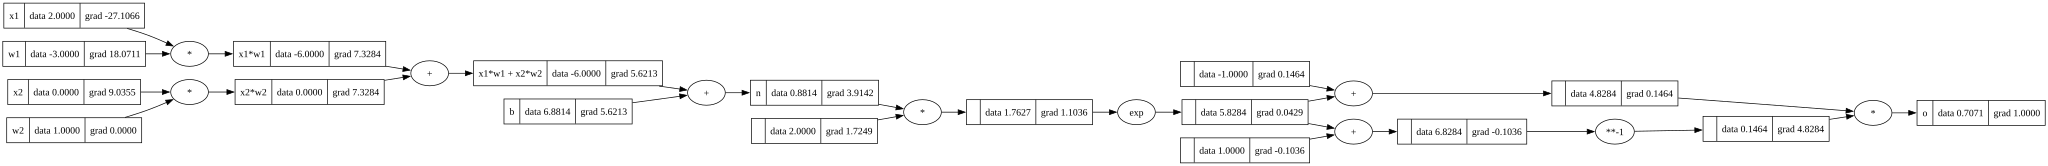

In [314]:
draw_dot(o)

In [302]:
o.backward()

o.data: 0.7071067811865477
e.grad: 0.04289321881345247
n.grad: 0.5


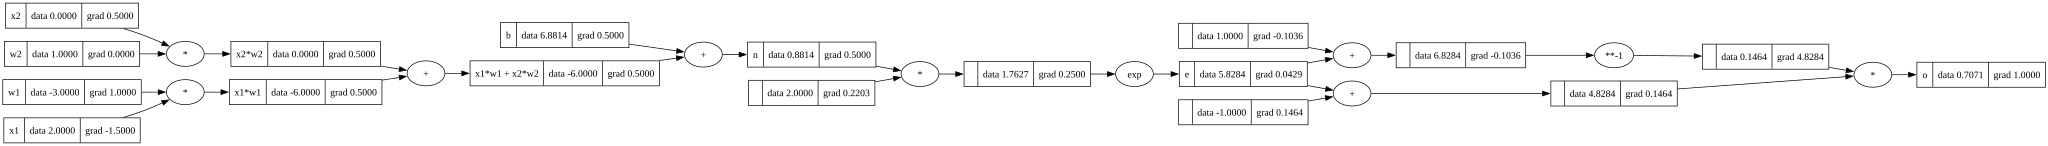

In [ ]:
# inputs x1, x2

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1, w2

w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron

b = Value(6.8813735870195432, label = 'b')

# x1 * w1 + x2 * w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# same as o = n.tanh() just written differnently
e = (2*n).exp() 
o = (e - 1) / (e + 1)
#
o.label = 'o'
o.backward()
e.label = 'e'
draw_dot(o)

## Doing the same thing in PyTorch

In [331]:
import torch

x1 = torch.Tensor([2.0]).double()                   ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                   ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()                  ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                   ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()     ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [332]:
torch.Tensor([[1, 2, 3], [4, 5, 6]])

tensor([[1., 2., 3.],
        [4., 5., 6.]])

In [373]:
import random

class Neuron:

    def __init__(self, nin):
        # nin = number of inputs to this neuron
        # one random weight per input, and one random bias, all in [-1, 1]
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # __call__ lets us use the object like a function: n(x)
        # computes w1*x1 + w2*x2 + ... + b
        # zip pairs each weight with its input; sum starts from the bias
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        # squash through tanh to get the output, in (-1, 1)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]


In [374]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])   # a neuron with 2 inputs
n(x)            # output changes each run, since weights are random

Value(label=, data=-0.05569741240966278)

In [375]:
n.parameters()

[Value(label=, data=0.8708200943787796),
 Value(label=, data=-0.7186765988421251),
 Value(label=, data=0.30269417519201736),
 Value(label=, data=0.25555413134325455),
 Value(label=, data=0.5680301753643309),
 Value(label=, data=0.17690160326160465),
 Value(label=, data=-0.9537057728263605),
 Value(label=, data=-0.14486963692130295),
 Value(label=, data=0.43035312271125803),
 Value(label=, data=0.06865840922560595),
 Value(label=, data=0.6987625838065255),
 Value(label=, data=0.7721874836922065),
 Value(label=, data=-0.49850399947299917),
 Value(label=, data=-0.40202322684099023),
 Value(label=, data=-0.0033592573036334006),
 Value(label=, data=0.486787142285928),
 Value(label=, data=-0.6104771335196111),
 Value(label=, data=0.039478044239989796),
 Value(label=, data=0.588562243630959),
 Value(label=, data=0.2584150649030339),
 Value(label=, data=0.4385691032285832),
 Value(label=, data=0.4652527315198889),
 Value(label=, data=-0.15246644550366129),
 Value(label=, data=-0.29790223466311

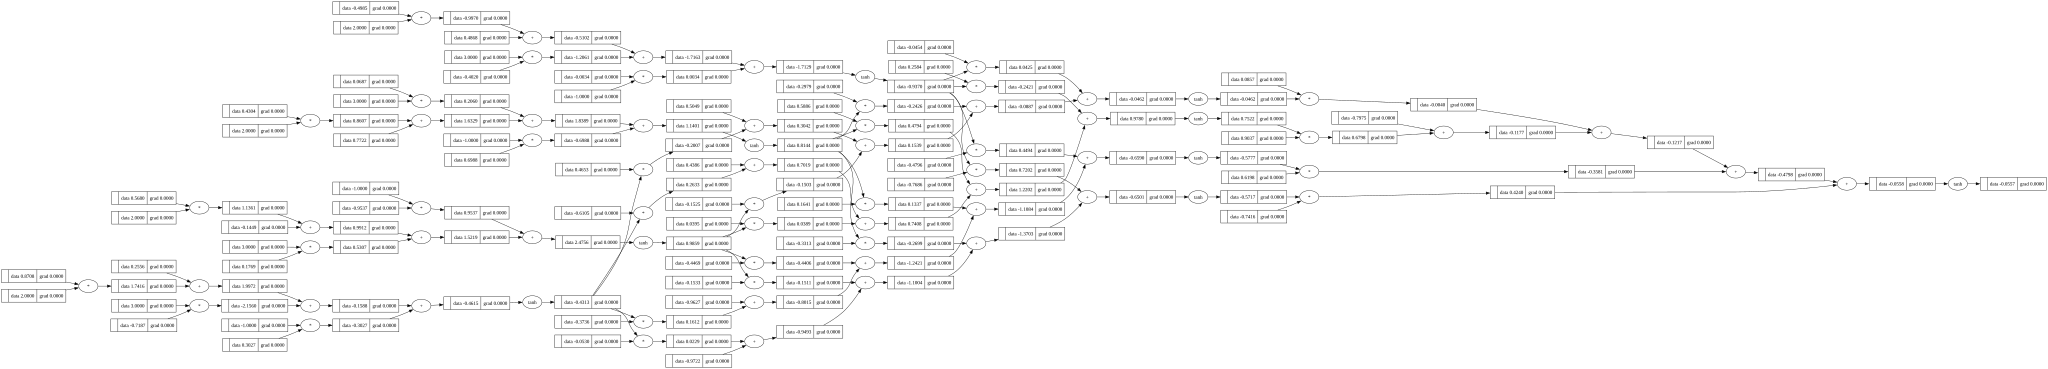

In [376]:
draw_dot(n(x))

In [377]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

ypred = [n(x) for x in xs]
ypred

[Value(label=, data=-0.05569741240966278),
 Value(label=, data=-0.41241177361207587),
 Value(label=, data=0.086251878735885),
 Value(label=, data=-0.21878691165998673)]

In [378]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(label=, data=4.125141630449092)

In [462]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(label=, data=0.004703167450003743)

In [460]:
loss.backward()

In [391]:
n.layers[0].neurons[0].w[0].grad

2.8806663343053582

In [392]:
n.layers[0].neurons[0].w[0].data

0.8546517490317252

In [461]:
for p in n.parameters():
    p.data += -0.001 * p.grad 

In [459]:
ypred

[Value(label=, data=0.9700653342754763),
 Value(label=, data=-0.9490637773210412),
 Value(label=, data=-0.9723105119732254),
 Value(label=, data=0.9666656326503636)]

In [463]:
n.parameters()

[Value(label=, data=-0.4889065095604294),
 Value(label=, data=-1.960850150585047),
 Value(label=, data=2.7126154224653956),
 Value(label=, data=0.01231421699795936),
 Value(label=, data=0.48952791913389454),
 Value(label=, data=0.2932251505484364),
 Value(label=, data=-0.8704542920052939),
 Value(label=, data=-0.09427854893945121),
 Value(label=, data=1.4135433495810363),
 Value(label=, data=1.2576614018802073),
 Value(label=, data=-0.2035381033853432),
 Value(label=, data=1.4803095846253183),
 Value(label=, data=-0.8289340975591059),
 Value(label=, data=0.11535435660857095),
 Value(label=, data=-0.7548914834515513),
 Value(label=, data=0.45227599511160366),
 Value(label=, data=-2.074427895535708),
 Value(label=, data=1.5227319349223931),
 Value(label=, data=-0.20853248895359097),
 Value(label=, data=0.06590794414825078),
 Value(label=, data=0.07615440864402563),
 Value(label=, data=0.33651307084529514),
 Value(label=, data=0.10415987781192423),
 Value(label=, data=-0.2582187194352454)

In [464]:
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x)

Value(label=, data=-0.04367590163086734)

In [465]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

In [468]:
for k in range(20):
  
  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
  
  # backward pass
  for p in n.parameters():
    p.grad = 0.0
  loss.backward()
  
  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad
  
  print(k, loss.data)

0 0.028243394391623888
1 0.026957723123557525
2 0.025782865296771068
3 0.02470506531802004
4 0.02371276067831394
5 0.022796160135844
6 0.021946916009829683
7 0.02115786687140604
8 0.02042283353784588
9 0.019736455878237077
10 0.01909406118681522
11 0.018491557204802785
12 0.017925344556643755
13 0.017392244602312902
14 0.016889439623541527
15 0.016414422947860587
16 0.01596495713293078
17 0.01553903872903713
18 0.015134868441594885
19 0.014750825750994845


In [469]:
ypred

[Value(label=, data=0.9407089027933369),
 Value(label=, data=-0.9272871309016678),
 Value(label=, data=-0.9548345493393696),
 Value(label=, data=0.937483503959868)]

# Lecture 1: Building micrograd

**Series:** Neural Networks: Zero to Hero (Andrej Karpathy)
**Video:** *The spelled-out intro to neural networks and backpropagation: building micrograd*
**Goal:** Build a tiny autograd engine from scratch, understand backpropagation deeply, and use it to train a small neural network.

---

## 1. The big picture

- A neural network is just a **big mathematical expression**: inputs combined with **weights** to produce an output.
- From the output we compute the **loss**: a single number measuring how wrong the network is.
- **Training** = adjusting the weights to make the loss smaller.
- To do that, we need to know, for every weight: *if I nudge this weight a little, does the loss go up or down, and by how much?* That is the weight's **gradient**.
- **Backpropagation** is the algorithm that computes all gradients efficiently, in one backward pass.
- **micrograd** is a tiny engine (~100 lines) that does this for scalars. PyTorch does the same thing for tensors, at scale.

---

## 2. The derivative as a "nudge"

For a function `f(x) = 3x² - 4x + 5`:

```python
h = 0.0001
x = 3.0
(f(x + h) - f(x)) / h   # ≈ 14
```

**Definition:** `f'(x) = lim (h → 0) of (f(x + h) - f(x)) / h`

- `f(x + h) - f(x)` → how much the output changed ("rise")
- `/ h` → divided by how much we nudged the input ("run")
- Result → the **slope**: the sensitivity of the output to the input

Analytically, `f'(x) = 6x - 4`, so `f'(3) = 14`. ✓

**Reading the sign:**

| Gradient | Meaning |
|---|---|
| positive | increasing x increases the output |
| negative | increasing x decreases the output |
| zero | output is flat here (e.g. the minimum at x = 2/3) |

**Reading the size:** a gradient of `g` means *nudging the input by h changes the output by about g × h*.

**About h:**
- Conceptually, h approaches 0, so the gradient doesn't depend on any particular h.
- In code, h must be small but **not too small**: with a tiny h, floating-point rounding errors dominate.
- The approximation is only accurate for **small** nudges, because most functions are curved.

---

## 3. Several inputs

```python
a = 2.0; b = -3.0; c = 10.0
d = a * b + c    # 4.0
```

Ask the nudge question **separately for each input**, holding the others fixed:

| Input | Gradient of d | Why |
|---|---|---|
| a | `b = -3` | d changes by b × (nudge) |
| b | `a = 2` | d changes by a × (nudge) |
| c | `1` | d changes by exactly the nudge |

---

## 4. The `Value` class and the computation graph

`Value` wraps a single number and remembers how it was made:

| Attribute | Meaning |
|---|---|
| `data` | the number itself |
| `grad` | its gradient: how much the final output changes when this value is nudged. Starts at `0.0` |
| `_prev` | the Values that created it (its "children") |
| `_op` | the operation that created it (`'+'`, `'*'`, `'tanh'`, ...) |
| `_backward` | a function that passes this node's gradient to its children |
| `label` | a name, for drawing the graph |

**How the graph is recorded:** when you write `c = a + b`, Python calls `a.__add__(b)`, which creates a new Value with `_prev = {a, b}` and `_op = '+'`. The graph exists entirely through these `_prev` links.

**Leaf nodes** (created directly, like `a = Value(2.0)`) have an empty `_prev`.

### Python details

- **Dunder methods** (`__add__`, `__mul__`, `__repr__`, `__call__`, ...) are called **automatically** by Python: `a + b` → `a.__add__(b)`, `print(a)` → `a.__repr__()`, `n(x)` → `n.__call__(x)`.
- **Leading underscore** (`_prev`, `_op`, `_backward`) = "internal, don't touch directly". A convention only; Python doesn't enforce it.
- **Reversed operators:** `2 * a` first tries `int.__mul__`, fails, then calls `a.__rmul__(2)`. Same for `__radd__` (needed by `sum()`, which starts from `0`).
- **Methods need `self`:** `o.backward()` becomes `Value.backward(o)`, so the definition must be `def backward(self):`.

---

## 5. Drawing the graph

`trace(root)` walks **backward** from the output through `_prev` (recursive depth-first search), collecting all nodes and edges. A `visited`/`nodes` set prevents visiting a node twice.

`draw_dot(root)` uses Graphviz to draw:
- a **record box** for each Value (`label | data | grad`)
- a small **op node** for each operation (`+`, `*`, ...)
- edges: child → op node → result

**Label formatting:**

```python
label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad)
# f-string equivalent (braces must be doubled):
label = f"{{ {n.label} | data {n.data:.4f} | grad {n.grad:.4f} }}"
```

- `%s` = insert string, `%.4f` = insert float with 4 decimals (Python)
- `|` splits the box into compartments, `{ }` controls layout direction (Graphviz record syntax)

---

## 6. Manual backpropagation

**Example expression:**

```python
a = Value(2.0);  b = Value(-3.0);  c = Value(10.0)
e = a * b        # -6
d = e + c        #  4
f = Value(-2.0)
L = d * f        # -8
```

```
a (2) ──┐
        (*) → e (-6) ──┐
b (-3) ─┘              (+) → d (4) ──┐
c (10) ────────────────┘             (*) → L (-8)
f (-2) ──────────────────────────────┘
```

### Step 1: start at the output

`L.grad = 1.0`. Nudging L by h changes L by 1 × h.

### Step 2: the multiplication rule, derived

For `L = d * f`, the derivative with respect to `d`:

```
(L(d + h) - L(d)) / h
= ((d + h)·f - d·f) / h
= (d·f + f·h - d·f) / h
= f·h / h
= f
```

**Rule for `*`:** each input's local derivative is **the other input**.

- `d.grad = f × L.grad = -2`
- `f.grad = d × L.grad = 4`

### Step 3: the chain rule

`e` only affects `L` *through* `d`. So:

```
dL/de = (dd/de) × (dL/dd)
       = local derivative × parent's gradient
```

**Analogy:** if 1 euro = 2 dollars and 1 dollar = 3 pesos, then 1 euro = 2 × 3 = 6 pesos. **Rates multiply along the chain.**

**Rule for `+`:** the local derivative is **1**, so `+` just **passes the gradient through** to both inputs (a "gradient distributor").

- `e.grad = 1 × d.grad = -2`
- `c.grad = 1 × d.grad = -2`

### Step 4: back to the inputs

- `a.grad = b × e.grad = -3 × -2 = 6`
- `b.grad = a × e.grad = 2 × -2 = -4`

### The recipe (for every node)

```
node.grad = (local derivative to my parent) × (parent.grad)
```

| Operation | Local derivative |
|---|---|
| `+` | 1 |
| `*` | the other input |
| `tanh` | `1 - tanh(x)²` = `1 - out²` |
| `exp` | `exp(x)` = `out` |
| `x**k` | `k · x**(k-1)` |

**Sanity check:** nudge `a` from 2.0 to 2.01, recompute, and L moves by ≈ +0.06 = 6 × 0.01. ✓

### Checking gradients numerically

Karpathy's `lol()` function builds the expression twice, once with one value nudged by h, and computes `(L2 - L1) / h`. This should match the manual gradient. Numerical checks are how you **verify** gradient code; they're too slow and approximate for training.

### Using the gradients

Nudge every input a small step **in the direction of its gradient**:

```python
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad
```

Recompute, and L goes from -8 to about -7.29: it **increased**, as predicted. This is one step of optimization. In training we step the **opposite** way (`-=`) to make the **loss go down**.

---

## 7. A neuron

```
n = x1*w1 + x2*w2 + b
o = tanh(n)
```

Values used: `x1 = 2, x2 = 0, w1 = -3, w2 = 1, b = 6.8813...`, giving `n ≈ 0.8814`, `o ≈ 0.7071`.

### Why an activation function (tanh)?

- Without one, a neuron is **linear**, and stacking linear layers just gives another linear function: `W2·(W1·x + b1) + b2 = (W2·W1)·x + ...`. Depth would be useless.
- A **nonlinearity** lets networks learn curved, complex patterns.
- `tanh` squashes values into (-1, 1), is smooth, zero-centered, and has a simple derivative (`1 - tanh²`).
- Downside: for large inputs it flattens out ("saturates"), gradients become ~0, and learning stalls. Modern networks mostly use **ReLU** or **GELU** (covered in later lectures).

### Manual backprop through the neuron

| Node | Gradient | How |
|---|---|---|
| `o` | 1.0 | start |
| `n` | 0.5 | `(1 - o²) × o.grad = (1 - 0.7071²) × 1` |
| `b` | 0.5 | `+` passes through |
| `x1w1 + x2w2` | 0.5 | `+` passes through |
| `x1w1`, `x2w2` | 0.5 | `+` passes through |
| `x1` | -1.5 | `w1 × 0.5 = -3 × 0.5` |
| `w1` | 1.0 | `x1 × 0.5 = 2 × 0.5` |
| `x2` | 0.5 | `w2 × 0.5 = 1 × 0.5` |
| `w2` | 0.0 | `x2 × 0.5 = 0 × 0.5` → x2 is 0, so w2 has no effect on o |

---

## 8. Automating backprop: `_backward`

Each operation stores its own local derivative rule in a `_backward` function, attached to the output Value:

```python
def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    def _backward():
        self.grad += other.data * out.grad
        other.grad += self.data * out.grad
    out._backward = _backward
    return out
```

- `_backward` computes **exact** gradients (calculus), unlike the numerical method, which only approximates them.
- Leaf nodes get the default `self._backward = lambda: None`.

### Why `+=` and not `=`

If a value is used **more than once** (e.g. `b = a + a`, or `e` used in both `e - 1` and `e + 1`), it affects the output through **several paths**. Its total gradient is the **sum** of the contributions from each path. With `=`, the second path would overwrite the first.

```
     ┌→ 3 ──┐
1 → 2       5      2.grad = contribution via 3 + contribution via 4
     └→ 4 ──┘
```

---

## 9. Order matters: topological sort

Each node's `_backward` needs its output's gradient to be **final** already. So backprop must start at the output and process a node only after **every node that depends on it**.

- **Chain** `1 → 2 → 3 → 4 → 5`: to get `2.grad`, we first need 3, 4, 5.
- **Branches**: nodes on separate branches aren't needed.
- **Shared nodes**: a node feeding several others needs all of them first.

A **topological sort** orders nodes so every node comes **after** its children. Reversing it gives the correct backprop order.

```python
def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
        if v not in visited:
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)          # added only after all its children
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
        node._backward()
```

Example result for the neuron (sibling order may vary, since `_prev` is a set):

```
[w1, x1, x1*w1, w2, x2, x2*w2, x1*w1 + x2*w2, b, n, o]
```

---

## 10. Breaking tanh into smaller operations

```python
e = (2*n).exp()
o = (e - 1) / (e + 1)
```

This needs more operations: `exp`, `__pow__`, `__truediv__`, `__sub__`, `__neg__`, `__rmul__`. The gradients come out **identical** to the single `tanh` version.

**Lesson:** you can implement an operation as one block with its own derivative, or as many small pieces. Backprop works either way; the choice is about convenience and efficiency.

Division is implemented as `self * other**-1`, and subtraction as `self + (-other)`, reusing existing operations.

---

## 11. Same thing in PyTorch

```python
import torch

x1 = torch.Tensor([2.0]).double();  x1.requires_grad = True
x2 = torch.Tensor([0.0]).double();  x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double();  w2.requires_grad = True
b  = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True

n = x1*w1 + x2*w2 + b
o = torch.tanh(n)
o.backward()

print(x1.grad.item(), w1.grad.item())   # -1.5, 1.0
```

- PyTorch computes exactly what micrograd computes, but on **tensors** (n-dimensional arrays), which makes it fast at scale.
- `.double()` = float64 precision (Python floats are float64 too).
- `requires_grad = True` is needed on leaf tensors so PyTorch tracks gradients.
- `.item()` only works on a tensor with **exactly one** element.

---

## 12. Building a neural network library

```python
import random

class Neuron:
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)   # w·x + b
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]

class Layer:
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
```

**Notes:**
- Weights start **random**: if they started identical, every neuron would learn the same thing.
- `zip(self.w, x)` pairs weights with inputs; `sum(..., self.b)` starts the sum from the bias.
- `MLP(3, [4, 4, 1])` = 3 inputs → hidden layer (4) → hidden layer (4) → output layer (1). The list **includes the output layer**. Two hidden layers, three `Layer` objects.
- Parameter count: (3×4 + 4) + (4×4 + 4) + (4×1 + 1) = 16 + 20 + 5 = **41**.

---

## 13. Loss and training

### Tiny dataset

```python
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]   # desired targets
```

### Mean squared error loss

```python
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
```

- Each term is 0 when the prediction equals the target, and grows as they differ.
- Squaring makes every error positive and punishes big errors more.

### Training loop (gradient descent)

```python
for k in range(20):
    # forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    # backward pass
    for p in n.parameters():
        p.grad = 0.0          # zero the gradients first!
    loss.backward()

    # update: step AGAINST the gradient to reduce the loss
    for p in n.parameters():
        p.data += -0.05 * p.grad

    print(k, loss.data)
```

**Key points:**
- The **minus sign** matters: a positive gradient means increasing the weight increases the loss, so we decrease it.
- **Zero the gradients** every step. Because `_backward` uses `+=`, gradients would otherwise pile up across steps. Karpathy makes this exact bug in the lecture; it's one of the most common bugs in neural network code (PyTorch's version: `optimizer.zero_grad()`).
- **Learning rate** (0.05 here): too small → slow; too large → the loss jumps around or diverges. Choosing it well is a key practical skill.
- Results vary between runs because the initial weights are random.

---

## 14. Summary

1. A **gradient** measures how much the final output changes when a value is nudged.
2. Each operation has a simple **local derivative**: `+` → 1, `*` → the other input, `tanh` → `1 - out²`.
3. The **chain rule**: multiply the local derivative by the parent's gradient.
4. Go **backward** from the output (in topological order), so each gradient takes one multiplication. That's why backprop scales to huge networks.
5. Use **`+=`** because a value used in several places sums its gradients.
6. **Training** = forward pass → zero grads → backward pass → update, repeated.
7. PyTorch does the same thing, on tensors.

---

## 15. Bugs I hit (and fixes)

| Symptom | Cause | Fix |
|---|---|---|
| `The module '.venv' could not be loaded` | PowerShell needs `.\` for relative paths | `.\.venv\Scripts\Activate.ps1` |
| `'Value' object has no attribute '_backward'` | Objects created with an old version of the class | Restart kernel + Run All |
| `backward() takes 0 positional arguments but 1 was given` | Missing `self` | `def backward(self):` |
| `unsupported operand type(s) for -: 'NoneType' and 'int'` | `exp` method missing `return out` | Add `return out` at the end |
| Wildly wrong gradients (e.g. `w1.grad = 18.07`) | Wrong indentation in `build_topo`: loop and `append` outside the `if` | Indent them inside `if v not in visited:` |
| `a Tensor with 2 elements cannot be converted to Scalar` | Wrote `[2,0]` instead of `[2.0]` | Use decimal points, not commas |
| `unhashable type: 'list'` in `draw_dot` | `n(x)` returned a list (a Layer/MLP output) | Use `n(x)[0]`, or return `outs[0]` when there's one neuron |
| `unsupported operand type(s) for +: 'int' and 'Value'` | `sum()` starts from 0; no `__radd__` | Add `def __radd__(self, other): return self + other` |
| Gradients doubled | Ran `backward()` twice (`+=` accumulates) | Rerun the cells that build the graph, or zero grads |

**General lesson:** after changing a class, **restart the kernel and Run All**, so every object is recreated with the new class.

---

## 16. Final `Value` class

```python
import math

class Value:

    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(label={self.label}, data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supports int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):      # other + self (needed by sum())
        return self + other

    def __rmul__(self, other):      # other * self (e.g. 2 * a)
        return self * other

    def __neg__(self):              # -self
        return self * -1

    def __sub__(self, other):       # self - other
        return self + (-other)

    def __truediv__(self, other):   # self / other
        return self * other**-1

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward()
```

---
